In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("./biometric.csv")
print(df["state"].unique())
bad_values = [
    "Darbhanga", "Puttenahalli", "Balanagar", "Jaipur",
    "Madanapalle", "Nagpur", "Raja Annamalai Puram", "100000","BALANAGAR"
]

df.drop(df[df['state'].isin(bad_values)].index, inplace=True)
df['state'].unique()

['Haryana' 'Bihar' 'Jammu and Kashmir' 'Tamil Nadu' 'Maharashtra'
 'Gujarat' 'Odisha' 'West Bengal' 'Kerala' 'Rajasthan' 'Punjab'
 'Himachal Pradesh' 'Uttar Pradesh' 'Assam' 'Uttarakhand' 'Madhya Pradesh'
 'Karnataka' 'Andhra Pradesh' 'Telangana' 'Goa' 'Nagaland' 'Jharkhand'
 'Delhi' 'Chhattisgarh' 'Meghalaya' 'Chandigarh' 'Orissa' 'Puducherry'
 'Pondicherry' 'Manipur' 'Sikkim' 'Tripura' 'Mizoram' 'Arunachal Pradesh'
 'Ladakh' 'Dadra and Nagar Haveli and Daman and Diu' 'Daman and Diu'
 'Andaman and Nicobar Islands' 'Andaman & Nicobar Islands'
 'Dadra and Nagar Haveli' 'Lakshadweep' 'Daman & Diu'
 'Dadra & Nagar Haveli' 'Jammu & Kashmir' 'WESTBENGAL' 'andhra pradesh'
 'Westbengal' 'West  Bengal' 'WEST BENGAL' 'West Bangal' 'ODISHA' 'odisha'
 'West bengal' 'west Bengal' 'Uttaranchal' 'Chhatisgarh' 'Tamilnadu']


array(['Haryana', 'Bihar', 'Jammu and Kashmir', 'Tamil Nadu',
       'Maharashtra', 'Gujarat', 'Odisha', 'West Bengal', 'Kerala',
       'Rajasthan', 'Punjab', 'Himachal Pradesh', 'Uttar Pradesh',
       'Assam', 'Uttarakhand', 'Madhya Pradesh', 'Karnataka',
       'Andhra Pradesh', 'Telangana', 'Goa', 'Nagaland', 'Jharkhand',
       'Delhi', 'Chhattisgarh', 'Meghalaya', 'Chandigarh', 'Orissa',
       'Puducherry', 'Pondicherry', 'Manipur', 'Sikkim', 'Tripura',
       'Mizoram', 'Arunachal Pradesh', 'Ladakh',
       'Dadra and Nagar Haveli and Daman and Diu', 'Daman and Diu',
       'Andaman and Nicobar Islands', 'Andaman & Nicobar Islands',
       'Dadra and Nagar Haveli', 'Lakshadweep', 'Daman & Diu',
       'Dadra & Nagar Haveli', 'Jammu & Kashmir', 'WESTBENGAL',
       'andhra pradesh', 'Westbengal', 'West  Bengal', 'WEST BENGAL',
       'West Bangal', 'ODISHA', 'odisha', 'West bengal', 'west Bengal',
       'Uttaranchal', 'Chhatisgarh', 'Tamilnadu'], dtype=object)

In [4]:
state_mapping = {
    # West Bengal variants
    "west Bengal": "West Bengal",
    "West  Bengal": "West Bengal",
    "Westbengal": "West Bengal",
    "WEST BENGAL": "West Bengal",
    "West Bangal": "West Bengal",
    "West bengal": "West Bengal",
    "WESTBENGAL": "West Bengal",
    "West Bengli": "West Bengal",

    # Odisha variants
    "odisha": "Odisha",
    "ODISHA": "Odisha",
    "Orissa": "Odisha",

    # Andhra Pradesh
    "andhra pradesh": "Andhra Pradesh",

    # Jammu & Kashmir
    "Jammu & Kashmir": "Jammu and Kashmir",

    # Chhattisgarh misspelling
    "Chhatisgarh": "Chhattisgarh",

    # Puducherry old name
    "Pondicherry": "Puducherry",

    # Uttarakhand old name
    "Uttaranchal": "Uttarakhand",

    # Daman & Diu
    "Daman & Diu": "Dadra and Nagar Haveli and Daman and Diu",
    "Daman and Diu": "Dadra and Nagar Haveli and Daman and Diu",

    # Dadra & Nagar Haveli
    "Dadra & Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Dadra and Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",

    # Andaman & Nicobar Islands
    "Andaman & Nicobar Islands": "Andaman and Nicobar Islands",
}

df['state'] = df['state'].replace(state_mapping)
df['state'].unique()

array(['Haryana', 'Bihar', 'Jammu and Kashmir', 'Tamil Nadu',
       'Maharashtra', 'Gujarat', 'Odisha', 'West Bengal', 'Kerala',
       'Rajasthan', 'Punjab', 'Himachal Pradesh', 'Uttar Pradesh',
       'Assam', 'Uttarakhand', 'Madhya Pradesh', 'Karnataka',
       'Andhra Pradesh', 'Telangana', 'Goa', 'Nagaland', 'Jharkhand',
       'Delhi', 'Chhattisgarh', 'Meghalaya', 'Chandigarh', 'Puducherry',
       'Manipur', 'Sikkim', 'Tripura', 'Mizoram', 'Arunachal Pradesh',
       'Ladakh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Andaman and Nicobar Islands', 'Lakshadweep', 'Tamilnadu'],
      dtype=object)

In [ ]:
df = df.drop_duplicates()
print(df.duplicated(subset=["pincode","date"]).sum())

df = df.groupby(["pincode", "date"], as_index=False).agg({"state": "first","bio_age_5_17": "sum","bio_age_17_": "sum"})

df = df.drop_duplicates()
print(df.duplicated(subset=["pincode","date"]).sum())

356719
0


In [8]:
df["total_enrollment"] = df["bio_age_17_"]+df["bio_age_5_17"]

In [10]:
df["date"] = pd.to_datetime(df["date"],format="%d-%m-%Y")
df['week'] = df['date'].dt.isocalendar().week
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [11]:
from scipy.stats import skew
monthly_skew = (
    df.groupby(["state", "month"])["total_enrollment"]
      .apply(lambda x: skew(x.dropna()))
      .reset_index(name="skewness")
)

KeyboardInterrupt: 

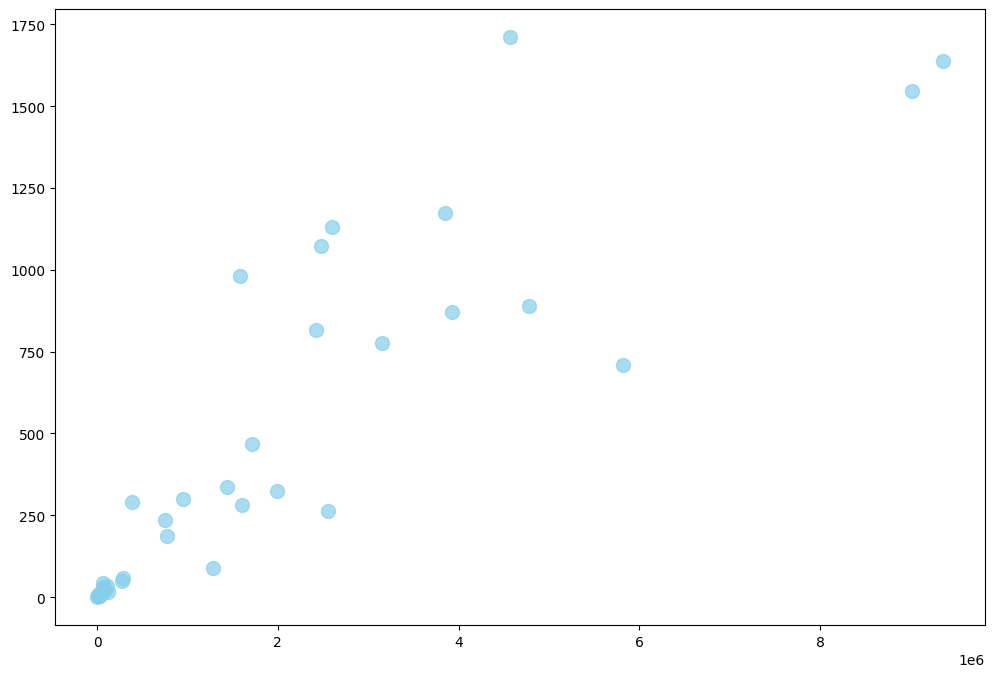

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset info: map their age columns to a common format
datasets = {
    "Biometric": {"file": "./biometric.csv", "col_map": {"bio_age_5_17": "age_5_17", "bio_age_17_": "age_17_"}},
    "Enrolment": {"file": "./enrolment.csv", "col_map": {"age_5_17": "age_5_17", "age_18_greater": "age_17_"}},
    "Demographic": {"file": "./demographic.csv", "col_map": {"demo_age_5_17": "age_5_17", "demo_age_17_": "age_17_"}}
}

# Bad state values to remove
bad_values = [
    "Darbhanga", "Puttenahalli", "Balanagar", "Jaipur",
    "Madanapalle", "Nagpur", "Raja Annamalai Puram", "100000","BALANAGAR"
]

# State name standardization
state_mapping = {
    "west Bengal": "West Bengal", "West  Bengal": "West Bengal", "Westbengal": "West Bengal",
    "WEST BENGAL": "West Bengal", "West Bangal": "West Bengal", "West bengal": "West Bengal",
    "WESTBENGAL": "West Bengal", "West Bengli": "West Bengal",
    "odisha": "Odisha", "ODISHA": "Odisha", "Orissa": "Odisha",
    "andhra pradesh": "Andhra Pradesh",
    "Jammu & Kashmir": "Jammu and Kashmir",
    "Chhatisgarh": "Chhattisgarh",
    "Pondicherry": "Puducherry",
    "Uttaranchal": "Uttarakhand",
    "Daman & Diu": "Dadra and Nagar Haveli and Daman and Diu",
    "Daman and Diu": "Dadra and Nagar Haveli and Daman and Diu",
    "Dadra & Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Dadra and Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
    "Andaman & Nicobar Islands": "Andaman and Nicobar Islands",
}

# Colors for each dataset
colors = {"Biometric": "skyblue", "Enrolment": "salmon", "Demographic": "lightgreen"}

plt.figure(figsize=(12, 8))

for name, info in datasets.items():
    df = pd.read_csv(info["file"])
    
    # Remove bad values
    df = df[~df["state"].isin(bad_values)]
    
    # Standardize state names
    df["state"] = df["state"].replace(state_mapping)
    
    # Rename age columns to common names
    df = df.rename(columns=info["col_map"])
    
    # Drop duplicates
    df = df.drop_duplicates()
    
    # Aggregate duplicates by pincode and date
    df = df.groupby(["pincode", "date"], as_index=False).agg({
        "state": "first",
        "age_5_17": "sum",
        "age_17_": "sum"
    })
    
    # Total enrollment & rolling mean
    df["total_enrollment"] = df["age_5_17"] + df["age_17_"]
    df["rolling_mean"] = df.groupby("pincode")["total_enrollment"].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )
    
    # Z-score for anomaly detection
    df["z_score"] = ((df["total_enrollment"] - df["rolling_mean"]) /
                     df.groupby("pincode")["total_enrollment"].transform("std"))
    df["anomaly_flag"] = (df["z_score"].abs() > 3).astype(int)
    
    # State summary
    state_summary = df.groupby("state").agg(
        total_enrollment=("total_enrollment", "sum"),
        anomalies=("anomaly_flag", "sum")
    ).reset_index()
    
    # Scatter plot for this dataset
    plt.scatter(
        state_summary["total_enrollment"],
        state_summary["anomalies"],
        s=100,
        color=colors[name],
        alpha=0.7,
        label=name
    )

plt.title("State-wise Total Enrollment vs Anomalous Days (All Datasets)")
plt.xlabel("Total Enrollment")
plt.ylabel("Number of Anomalous Days")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()


In [ ]:
state_demographics = {
    "Delhi": {"population": 22_300_000, "literacy_rate": 88.7},
    "Haryana": {"population": 30_900_000, "literacy_rate": 80.4},
    "Uttar Pradesh": {"population": 241_000_000, "literacy_rate": 73.0},
    "Punjab": {"population": 31_000_000, "literacy_rate": 83.7},
    "Chandigarh": {"population": 1_240_000, "literacy_rate": 86.4},
    "Himachal Pradesh": {"population": 7_540_000, "literacy_rate": 86.6},
    "Jammu and Kashmir": {"population": 13_700_000, "literacy_rate": 77.3},
    "Ladakh": {"population": 300_000, "literacy_rate": 77.0},
    "Uttarakhand": {"population": 10_100_000, "literacy_rate": 87.6},
    "Rajasthan": {"population": 81_900_000, "literacy_rate": 69.7},
    "Gujarat": {"population": 73_200_000, "literacy_rate": 82.4},
    "Dadra and Nagar Haveli and Daman and Diu": {"population": 670_000, "literacy_rate": 87.1},
    "Maharashtra": {"population": 128_000_000, "literacy_rate": 84.8},
    "Goa": {"population": 1_600_000, "literacy_rate": 87.4},
    "Madhya Pradesh": {"population": 87_600_000, "literacy_rate": 73.7},
    "Chhattisgarh": {"population": 30_800_000, "literacy_rate": 77.3},
    "Andhra Pradesh": {"population": 53_500_000, "literacy_rate": 72.6},
    "Telangana": {"population": 38_200_000, "literacy_rate": 72.8},
    "Tamil Nadu": {"population": 76_500_000, "literacy_rate": 82.9},
    "Puducherry": {"population": 1_650_000, "literacy_rate": 86.6},
    "Karnataka": {"population": 68_000_000, "literacy_rate": 77.2},
    "Kerala": {"population": 36_000_000, "literacy_rate": 96.2},
    "Lakshadweep": {"population": 74_000, "literacy_rate": 92.3},
    "West Bengal": {"population": 99_500_000, "literacy_rate": 80.5},
    "Sikkim": {"population": 700_000, "literacy_rate": 82.2},
    "Andaman and Nicobar Islands": {"population": 405_000, "literacy_rate": 87.0},
    "Odisha": {"population": 41_900_000, "literacy_rate": 77.3},
    "Assam": {"population": 36_300_000, "literacy_rate": 85.9},
    "Meghalaya": {"population": 3_400_000, "literacy_rate": 75.5},
    "Arunachal Pradesh": {"population": 1_600_000, "literacy_rate": 67.0},
    "Manipur": {"population": 3_100_000, "literacy_rate": 79.9},
    "Mizoram": {"population": 1_200_000, "literacy_rate": 91.3},
    "Nagaland": {"population": 2_300_000, "literacy_rate": 80.1},
    "Tripura": {"population": 4_100_000, "literacy_rate": 87.8},
    "Bihar": {"population": 128_500_000, "literacy_rate": 70.9},
    "Jharkhand": {"population": 40_000_000, "literacy_rate": 74.3}
}

df["population"] = df["state"].map(
    lambda s: state_demographics[s]["population"]
)
df["literacy_rate"] = df["state"].map(
    lambda s: state_demographics[s]["literacy_rate"]
)

df["normalized_enrollment"] = df["total_enrollment"] / df["population"]

df["normalized_enrollment_norm"] = (
    df["normalized_enrollment"] - df["normalized_enrollment"].min()
) / (
    df["normalized_enrollment"].max() - df["normalized_enrollment"].min()
)

state_enrollment = (
    df.groupby("state", as_index=False)
      .agg(
          normalized_enrollment_norm=("normalized_enrollment_norm", "mean")
      )
)


In [16]:
# Calculate no. of anomalous days per state
df["anomaly"] = df["z_score"].abs() > 3
df["anomaly"] = df["anomaly"].astype(int)
state_anomalies = df.groupby("state")["anomaly"].sum().sort_values()
state_anomalies

state
Tamilnadu                                      0
Dadra and Nagar Haveli and Daman and Diu       4
Ladakh                                         4
Lakshadweep                                    5
Andaman and Nicobar Islands                    7
Sikkim                                         9
Mizoram                                       15
Chandigarh                                    18
Meghalaya                                     23
Puducherry                                    24
Arunachal Pradesh                             31
Nagaland                                      35
Goa                                           43
Manipur                                       49
Tripura                                       58
Delhi                                         90
Jammu and Kashmir                            188
Uttarakhand                                  237
Chhattisgarh                                 263
Haryana                                      282
Himachal Prade

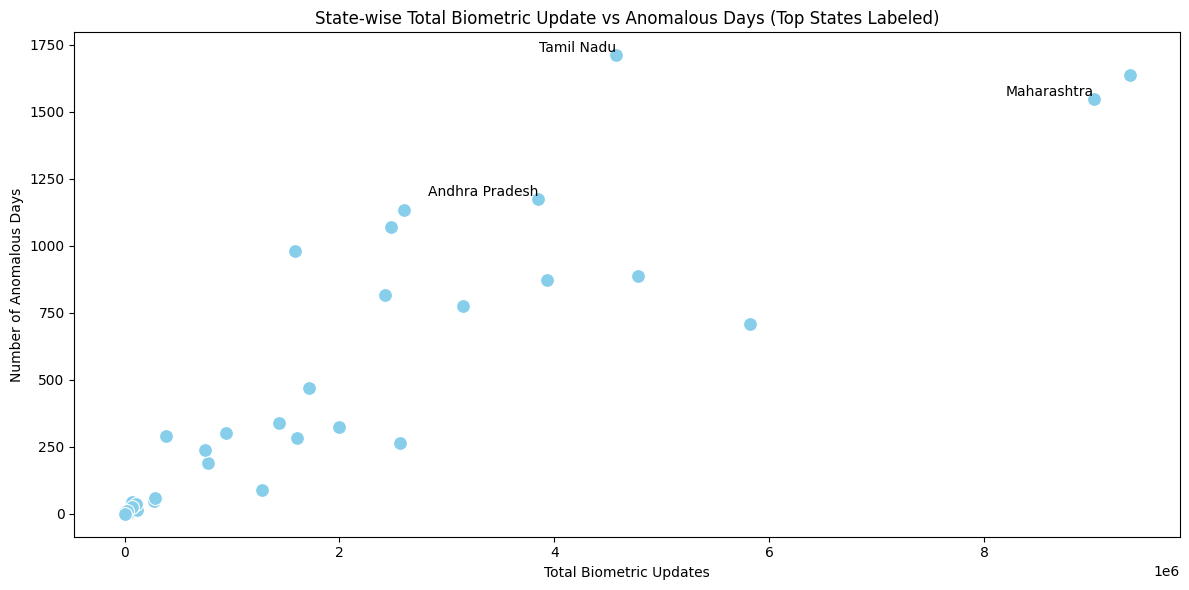

In [20]:
# Compute total enrollment & anomalies
df["anomaly_flag"] = (df["z_score"].abs() > 3).astype(int)

state_summary = df.groupby("state").agg(
    total_enrollment=("total_enrollment", "sum"),
    anomalies=("anomaly_flag", "sum")
).reset_index()

# Find the state with the highest total enrollment
highest_enrollment_state = state_summary.loc[state_summary["total_enrollment"].idxmax(), "state"]

# Select top anomalous states excluding the state with highest total enrollment
top_states = (
    state_summary[state_summary["state"] != highest_enrollment_state]
    .nlargest(3, "anomalies")
)

# Scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=state_summary,
    x="total_enrollment",
    y="anomalies",
    s=100,
    color="skyblue"
)

# Add labels only for selected top states
for i, row in top_states.iterrows():
    plt.text(
        row["total_enrollment"],
        row["anomalies"],
        row["state"],
        fontsize=10,
        ha="right",
        va="bottom"
    )

plt.title("State-wise Total Biometric Update vs Anomalous Days (Top States Labeled)")
plt.xlabel("Total Biometric Updates")
plt.ylabel("Number of Anomalous Days")
plt.tight_layout()
plt.show()
